# Spam Email Detection using NLP
Complete pipeline: load data -> NLP text preprocessing (tokenize, remove stopwords, lemmatize) -> TF-IDF features -> train/compare models -> evaluate -> save best model.

Every slow step prints progress so it never *looks* frozen.

In [1]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn nltk joblib -q

In [4]:
import os
import re
import time
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [6]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mouni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mouni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mouni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mouni\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mouni\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 1. Load the dataset

In [8]:
import kagglehub

path = kagglehub.dataset_download(
    "meruvulikith/190k-spam-ham-email-dataset-for-classification"
)
print("Path to dataset files:", path)

Path to dataset files: C:\Users\mouni\.cache\kagglehub\datasets\meruvulikith\190k-spam-ham-email-dataset-for-classification\versions\1


In [10]:
csv_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:", csv_files)

CSV files found: ['C:\\Users\\mouni\\.cache\\kagglehub\\datasets\\meruvulikith\\190k-spam-ham-email-dataset-for-classification\\versions\\1\\spam_Emails_data.csv']


In [14]:
df = pd.read_csv(csv_files[0])
print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (193852, 2)


,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


## 2. (Optional) Use a smaller sample while testing
The full dataset has ~190k rows. NLP tokenization/lemmatization over the whole thing can take several minutes. Set `USE_SAMPLE = True` first to confirm the whole pipeline works end to end in under a minute, then switch to `False` and rerun everything on the full data.

In [16]:
USE_SAMPLE = True     # <-- set to False once you've confirmed the pipeline works
SAMPLE_SIZE = 15000

df.columns = df.columns.str.strip()
df = df.dropna(subset=["text", "label"])

if USE_SAMPLE and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print("Working with", len(df), "rows")

Working with 15000 rows


## 3. Clean labels and remove duplicates

In [18]:
print(df["label"].unique())

if df["label"].dtype == object:
    df["label"] = df["label"].map({"Ham": 0, "Spam": 1})

df = df.drop_duplicates(subset=["text"])
df["text"] = df["text"].astype(str)

print(df["label"].value_counts())
print("Shape after cleanup:", df.shape)

['Ham' 'Spam']
label
0    7800
1    7200
Name: count, dtype: int64
Shape after cleanup: (15000, 2)


## 4. Exploratory plots

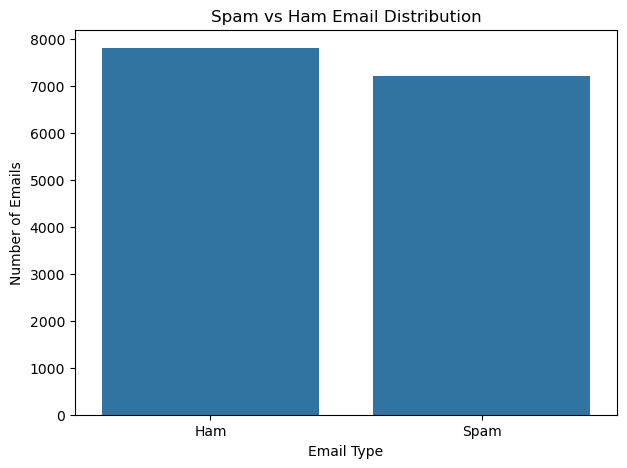

In [20]:
df["email_length"] = df["text"].apply(len)

plt.figure(figsize=(7, 5))
sns.countplot(x=df["label"].map({0: "Ham", 1: "Spam"}))
plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.show()

## 5. NLP text preprocessing
This is the core NLP step: lowercase -> strip HTML/URLs/emails/punctuation -> **tokenize** -> **remove stopwords** -> **lemmatize**. A progress counter prints every 2000 rows so you can see it's actively working on the full dataset.

In [22]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)                 # remove HTML
    text = re.sub(r"http\S+|www\S+", " ", text)        # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)               # remove emails
    text = re.sub(r"[^a-zA-Z\s]", " ", text)            # keep only letters
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)                       # tokenize
    tokens = [w for w in tokens if w not in stop_words] # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]  # lemmatize

    return " ".join(tokens)

In [ ]:
sample = df["text"].iloc[0]
print("ORIGINAL:\n", sample[:300])
print("\nPROCESSED:\n", preprocess_text(sample)[:300])

In [24]:
start = time.time()
processed = []

for i, text in enumerate(df["text"]):
    processed.append(preprocess_text(text))
    if (i + 1) % 2000 == 0:
        print(f"Processed {i + 1}/{len(df)} rows... ({time.time() - start:.1f}s elapsed)")

df["clean_text"] = processed
print(f"Done. Processed {len(df)} rows in {time.time() - start:.1f}s")
df[["text", "clean_text"]].head()

Processed 2000/15000 rows... (16.3s elapsed)
Processed 4000/15000 rows... (25.7s elapsed)
Processed 6000/15000 rows... (34.2s elapsed)
Processed 8000/15000 rows... (42.5s elapsed)
Processed 10000/15000 rows... (50.0s elapsed)
Processed 12000/15000 rows... (58.8s elapsed)
Processed 14000/15000 rows... (67.2s elapsed)
Done. Processed 15000 rows in 71.6s


,text,clean_text
0,ets intranet consolidation project updates ( w...,ets intranet consolidation project update www ...
1,article written tamim ansary afghani american ...,article written tamim ansary afghani american ...
2,kevin attached electricity price discovery res...,kevin attached electricity price discovery res...
3,cnat calm possible sir original message maggi ...,cnat calm possible sir original message maggi ...
4,there are now two house hearnigs tomorrow not ...,two house hearnigs tomorrow one morning panel ...


## 6. Train/test split + TF-IDF vectorization

In [26]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12000
Testing samples: 3000


In [28]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 1),      # start with unigrams only - fast and reliable
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    max_features=20000
)

print("Fitting TF-IDF on training data...")
start = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
print(f"Fit done in {time.time() - start:.1f}s. Shape: {X_train_tfidf.shape}")

X_test_tfidf = tfidf.transform(X_test)
print("Test set transformed. Shape:", X_test_tfidf.shape)

Fitting TF-IDF on training data...
Fit done in 4.3s. Shape: (12000, 20000)
Test set transformed. Shape: (3000, 20000)


## 7. Train and compare models

In [30]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVC": LinearSVC()
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    predictions[name] = preds

    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds)
    }

    print(classification_report(y_test, preds, target_names=["Ham", "Spam"]))

Training Naive Bayes...
              precision    recall  f1-score   support

         Ham       0.92      0.97      0.94      1560
        Spam       0.97      0.91      0.94      1440

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000

Training Logistic Regression...
              precision    recall  f1-score   support

         Ham       0.97      0.95      0.96      1560
        Spam       0.95      0.97      0.96      1440

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000

Training Linear SVC...
              precision    recall  f1-score   support

         Ham       0.98      0.96      0.97      1560
        Spam       0.96      0.98      0.97      1440

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      

In [32]:
results_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
results_df

,accuracy,precision,recall,f1
Linear SVC,0.971667,0.962457,0.979167,0.970740
Logistic Regression,0.963333,0.951766,0.972917,0.962225
Naive Bayes,0.941000,0.966741,0.908333,0.936627


## 8. Best model + confusion matrix

Best model: Linear SVC


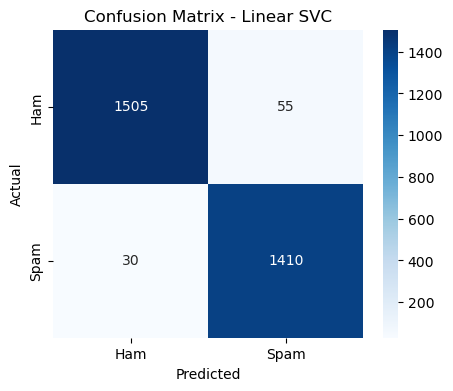

In [34]:
best_name = results_df["f1"].idxmax()
best_model = models[best_name]
best_preds = predictions[best_name]

print("Best model:", best_name)

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 9. Save model + vectorizer

In [36]:
joblib.dump(best_model, "spam_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Saved: spam_classifier.pkl, tfidf_vectorizer.pkl")

Saved: spam_classifier.pkl, tfidf_vectorizer.pkl


## 10. Test on a new email

In [38]:
def predict_email(text, model=best_model, vectorizer=tfidf):
    cleaned = preprocess_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "Spam" if pred == 1 else "Ham"

sample_email = """
Congratulations!!! You have won $1000.
Click https://example.com to claim your prize.
"""

print(predict_email(sample_email))

Spam


In [40]:
# Interactive spam checker
while True:
    user_email = input("\nEnter an email text to check (or type 'exit' to stop):\n> ")
    
    if user_email.strip().lower() == "exit":
        print("Stopped.")
        break
    
    if user_email.strip() == "":
        print("Please enter some text.")
        continue
    
    cleaned = preprocess_text(user_email)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    
    result = "SPAM 🚫" if pred == 1 else "HAM ✅ (not spam)"
    print(f"Prediction: {result}")
    
    # If the model supports probability scores, show confidence too
    if hasattr(best_model, "predict_proba"):
        proba = best_model.predict_proba(vec)[0]
        print(f"Confidence — Ham: {proba[0]*100:.1f}%, Spam: {proba[1]*100:.1f}%")


Enter an email text to check (or type 'exit' to stop):
>  Congratulations! You have been selected to win a FREE iPhone 15. Click here now to claim your prize before it expires: http://claim-your-prize.com


Prediction: SPAM 🚫



Enter an email text to check (or type 'exit' to stop):
>  Hi John, just following up on our meeting yesterday. Can you send me the updated project timeline by Friday? Thanks, Sarah


Prediction: HAM ✅ (not spam)



Enter an email text to check (or type 'exit' to stop):
>  URGENT: Your account has been suspended. Verify your bank details immediately to avoid permanent closure. Click the link below.


Prediction: SPAM 🚫



Enter an email text to check (or type 'exit' to stop):
>  Hey, are we still on for lunch tomorrow at 1pm? Let me know if that time works for you.


Prediction: HAM ✅ (not spam)



Enter an email text to check (or type 'exit' to stop):
>  exit


Stopped.


## Notes
- Set `USE_SAMPLE = False` in step 2 and rerun the notebook top to bottom to train on the full ~190k rows once you've confirmed everything works.
- Progress prints in steps 5 and 6 mean the notebook will never look silently frozen - if output stops appearing for several minutes with no new lines, that's when something is actually stuck.
- To improve accuracy further: try `ngram_range=(1, 2)` in the TF-IDF cell (slower), or increase `max_features`.